In [1]:
# Проверяем что установлено сейчас
!pip list | grep -E "(torch|tensorflow|cuda|nvidia)"
!nvidia-smi  # Проверяем версию CUDA
!nvcc --version  # Проверяем компилятор CUDA

nvidia-cublas-cu12                 12.8.4.1
nvidia-cuda-cupti-cu12             12.8.90
nvidia-cuda-nvcc-cu12              12.9.86
nvidia-cuda-nvrtc-cu12             12.8.93
nvidia-cuda-runtime-cu12           12.8.90
nvidia-cudnn-cu12                  9.10.2.21
nvidia-cufft-cu12                  11.3.3.83
nvidia-cufile-cu12                 1.13.1.3
nvidia-curand-cu12                 10.3.9.90
nvidia-cusolver-cu12               11.7.3.90
nvidia-cusparse-cu12               12.5.8.93
nvidia-cusparselt-cu12             0.7.1
nvidia-nccl-cu12                   2.27.5
nvidia-nvjitlink-cu12              12.8.93
nvidia-nvshmem-cu12                3.3.20
nvidia-nvtx-cu12                   12.8.90
open_clip_torch                    3.2.0
pytorch-lightning                  2.5.5
tensorflow                         2.20.0
tensorflow-io-gcs-filesystem       0.37.1
tensorflow-text                    2.19.0
torch                              2.9.0
torchaudio                         2.5.1+cu121
torchmet

In [2]:
# Текущая директория + путь к датасету

import os
HOME = os.getcwd()
print(HOME)
print('-----------------------')
# Пути
IMAGE_PATH = "/home/oleg/projects/ML/Bacterial_Colony/Colony_dataset"

os.listdir(IMAGE_PATH)

/home/oleg/projects/ML/Bacterial_Colony
-----------------------


['Lactobacillus.rhamnosus',
 'Clostridium.perfringens',
 'Micrococcus.spp',
 'Lactobacillus.crispatus',
 'Veionella',
 'Streptococcus.agalactiae',
 'Enterococcus.faecalis',
 'Propionibacterium.acnes',
 'Fusobacterium',
 'Neisseria.gonorrhoeae',
 'Lactobacillus.casei',
 'Acinetobacter.baumanii',
 'Proteus',
 'Bacteroides.fragilis',
 'Lactobacillus.reuteri',
 'Actinomyces.israeli',
 'Escherichia.coli',
 'Candida.albicans',
 'Staphylococcus.saprophiticus',
 'Lactobacillus.salivarius',
 'Staphylococcus.epidermidis',
 'Lactobacillus.johnsonii',
 'Enterococcus.faecium',
 'Lactobacillus.paracasei',
 'Bifidobacterium.spp',
 'Lactobacillus.gasseri',
 'Porfyromonas.gingivalis',
 'Staphylococcus.aureus',
 'Listeria.monocytogenes',
 'Lactobacillus.plantarum',
 'Pseudomonas.aeruginosa',
 'Lactobacillus.delbrueckii',
 'Lactobacillus.jehnsenii']

In [12]:
# Конвертер в jpg
'''
import os
from PIL import Image
import shutil

def convert_tif_to_png(source_dir, target_dir):
    """Конвертирует все .tif файлы в .png"""
    if os.path.exists(target_dir):
        shutil.rmtree(target_dir)
    os.makedirs(target_dir)
    
    for class_name in os.listdir(source_dir):
        class_path = os.path.join(source_dir, class_name)
        target_class_path = os.path.join(target_dir, class_name)
        
        if os.path.isdir(class_path):
            os.makedirs(target_class_path, exist_ok=True)
            
            for file in os.listdir(class_path):
                if file.lower().endswith(('.tif', '.tiff')):
                    # Открываем .tif и сохраняем как .png
                    tif_path = os.path.join(class_path, file)
                    png_path = os.path.join(target_class_path, 
                                          file.replace('.tif', '.png').replace('.tiff', '.png'))
                    
                    try:
                        with Image.open(tif_path) as img:
                            img.save(png_path, 'PNG')
                        print(f"Converted: {file} -> {os.path.basename(png_path)}")
                    except Exception as e:
                        print(f"Error converting {file}: {e}")

# Конвертируем
SOURCE_PATH = "/home/oleg/.cache/kagglehub/datasets/samaarashidaarbi/dibas-bacterial-colony-dataset/versions/1"
TARGET_PATH = "/home/oleg/projects/ML/Bacterial_Colony/Colony_dataset"

print("🔄 Converting .tif to .png...")
convert_tif_to_png(SOURCE_PATH, TARGET_PATH)
print("✅ Conversion complete!")


'''

🔄 Converting .tif to .png...
Converted: Lactobacillus.rhamnosus_0020.tif -> Lactobacillus.rhamnosus_0020.png
Converted: Lactobacillus.rhamnosus_0008.tif -> Lactobacillus.rhamnosus_0008.png
Converted: Lactobacillus.rhamnosus_0009.tif -> Lactobacillus.rhamnosus_0009.png
Converted: Lactobacillus.rhamnosus_0010.tif -> Lactobacillus.rhamnosus_0010.png
Converted: Lactobacillus.rhamnosus_0011.tif -> Lactobacillus.rhamnosus_0011.png
Converted: Lactobacillus.rhamnosus_0014.tif -> Lactobacillus.rhamnosus_0014.png
Converted: Lactobacillus.rhamnosus_0007.tif -> Lactobacillus.rhamnosus_0007.png
Converted: Lactobacillus.rhamnosus_0016.tif -> Lactobacillus.rhamnosus_0016.png
Converted: Lactobacillus.rhamnosus_0002.tif -> Lactobacillus.rhamnosus_0002.png
Converted: Lactobacillus.rhamnosus_0015.tif -> Lactobacillus.rhamnosus_0015.png
Converted: Lactobacillus.rhamnosus_0001.tif -> Lactobacillus.rhamnosus_0001.png
Converted: Lactobacillus.rhamnosus_0006.tif -> Lactobacillus.rhamnosus_0006.png
Converted: 

/home/oleg/miniconda3/envs/tensflow/lib/python3.11/site-packages/PIL/TiffImagePlugin.py:949: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Converted: Micrococcus.spp_0001.tif -> Micrococcus.spp_0001.png
Converted: Micrococcus.spp_0017.tif -> Micrococcus.spp_0017.png
Converted: Micrococcus.spp_0005.tif -> Micrococcus.spp_0005.png
Converted: Micrococcus.spp_0022.tif -> Micrococcus.spp_0022.png
Converted: Micrococcus.spp_0006.tif -> Micrococcus.spp_0006.png
Converted: Micrococcus.spp_0009.tif -> Micrococcus.spp_0009.png
Converted: Micrococcus.spp_0003.tif -> Micrococcus.spp_0003.png
Converted: Micrococcus.spp_0015.tif -> Micrococcus.spp_0015.png
Converted: Micrococcus.spp_0012.tif -> Micrococcus.spp_0012.png
Converted: Lactobacillus.crispatus_0010.tif -> Lactobacillus.crispatus_0010.png
Converted: Lactobacillus.crispatus_0015.tif -> Lactobacillus.crispatus_0015.png
Converted: Lactobacillus.crispatus_0019.tif -> Lactobacillus.crispatus_0019.png
Converted: Lactobacillus.crispatus_0009.tif -> Lactobacillus.crispatus_0009.png
Converted: Lactobacillus.crispatus_0012.tif -> Lactobacillus.crispatus_0012.png
Converted: Lactobacillus

In [1]:

IMAGE_PATH = "/home/oleg/projects/ML/Bacterial_Colony/Colony_dataset"

In [14]:
# Простой анализ датасета с визуализацией

import os
import matplotlib.pyplot as plt
import numpy as np

def analyze_dataset_simple(dataset_path):
    """
    Простой анализ датасета с визуализацией
    """
    # Проверяем существование пути
    if not os.path.exists(dataset_path):
        print(f"❌ Ошибка: путь '{dataset_path}' не существует")
        return None
    
    # Получаем список классов
    class_names = [d for d in os.listdir(dataset_path) 
                  if os.path.isdir(os.path.join(dataset_path, d))]
    class_names.sort()
    
    if not class_names:
        print("❌ В датасете не найдено папок с классами")
        return None
    
    # Подсчет файлов
    class_counts = {}
    total_files = 0
    
    print("📊 АНАЛИЗ ДАТАСЕТА:")
    for class_name in class_names:
        class_path = os.path.join(dataset_path, class_name)
        image_files = [f for f in os.listdir(class_path) 
                      if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', 'tif'))]
        count = len(image_files)
        class_counts[class_name] = count
        total_files += count
        print(f"  {class_name}: {count} файлов")
    
    print(f"📈 ИТОГО: {total_files} изображений, {len(class_names)} классов")
    
    # Визуализация
    plt.figure(figsize=(12, 8))
    
    classes = list(class_counts.keys())
    counts = list(class_counts.values())
    
    # Создаем диаграмму
    bars = plt.bar(classes, counts, color=plt.cm.Set3(np.linspace(0, 1, len(classes))), 
                   edgecolor='black', alpha=0.8)
    
    # Настройки графика
    plt.title(f'Распределение изображений по классам\nВсего: {total_files} изображений, {len(class_names)} классов', 
              fontsize=14, fontweight='bold', pad=20)
    plt.xlabel('Классы', fontsize=12)
    plt.ylabel('Количество изображений', fontsize=12)
    
    # Поворачиваем подписи и выравниваем
    plt.xticks(rotation=45, ha='right')
    
    # Добавляем значения на столбцы
    for bar, count in zip(bars, counts):
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + max(counts)*0.01,
                f'{count}', ha='center', va='bottom', fontweight='bold', fontsize=10)
    
    # Добавляем сетку для удобства чтения
    plt.grid(True, axis='y', alpha=0.3, linestyle='--')
    
    # Настраиваем отступы
    plt.tight_layout()
    
    plt.show()
    
    return {'class_names': class_names, 'class_counts': class_counts, 'total_files': total_files}

# ИСПОЛЬЗОВАНИЕ:
# Просто вызовите функцию с путем к вашему датасету
result = analyze_dataset_simple(IMAGE_PATH)

📊 АНАЛИЗ ДАТАСЕТА:
  Acinetobacter.baumanii: 20 файлов
  Actinomyces.israeli: 23 файлов
  Bacteroides.fragilis: 23 файлов
  Bifidobacterium.spp: 23 файлов
  Candida.albicans: 20 файлов
  Clostridium.perfringens: 23 файлов
  Enterococcus.faecalis: 20 файлов
  Enterococcus.faecium: 20 файлов
  Escherichia.coli: 20 файлов
  Fusobacterium: 23 файлов
  Lactobacillus.casei: 20 файлов
  Lactobacillus.crispatus: 20 файлов
  Lactobacillus.delbrueckii: 20 файлов
  Lactobacillus.gasseri: 20 файлов
  Lactobacillus.jehnsenii: 20 файлов
  Lactobacillus.johnsonii: 20 файлов
  Lactobacillus.paracasei: 20 файлов
  Lactobacillus.plantarum: 20 файлов
  Lactobacillus.reuteri: 20 файлов
  Lactobacillus.rhamnosus: 20 файлов
  Lactobacillus.salivarius: 20 файлов
  Listeria.monocytogenes: 22 файлов
  Micrococcus.spp: 21 файлов
  Neisseria.gonorrhoeae: 23 файлов
  Porfyromonas.gingivalis: 23 файлов
  Propionibacterium.acnes: 23 файлов
  Proteus: 20 файлов
  Pseudomonas.aeruginosa: 20 файлов
  Staphylococcus.au

<Figure size 1200x800 with 1 Axes>

In [12]:
# Показано по 1 случайному изображению из каждой категорий

from PIL import Image
import os
import matplotlib.pyplot as plt
import random

# Создаем график 2x5
fig, axes = plt.subplots(5, 7, figsize=(15, 6))
axes = axes.ravel()

categories = os.listdir(IMAGE_PATH)
plot_index = 0

for category in categories:
    category_path = os.path.join(IMAGE_PATH, category)
    file_names = os.listdir(category_path)
    
    # Берем 1 случайное изображение из каждой категории
    if file_names:
        random_file = random.choice(file_names)
        img_path = os.path.join(category_path, random_file)
        img = Image.open(img_path)
        
        axes[plot_index].imshow(img)
        axes[plot_index].set_title(f"{category}", fontsize=12)
        axes[plot_index].axis('off')
        plot_index += 1

# Скрываем лишние subplot'ы
for i in range(plot_index, len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.show()

print(f"🎲 Показано по 1 случайному изображению из {plot_index} категорий")

<Figure size 1500x600 with 35 Axes>

🎲 Показано по 1 случайному изображению из 33 категорий


In [13]:
# Показано по 1 случайному изображению из каждой категорий

from PIL import Image
import os
import matplotlib.pyplot as plt
import random

# Создаем график 2x5
fig, axes = plt.subplots(5, 7, figsize=(15, 6))
axes = axes.ravel()

categories = os.listdir(IMAGE_PATH)
plot_index = 0

for category in categories:
    category_path = os.path.join(IMAGE_PATH, category)
    file_names = os.listdir(category_path)
    
    # Берем 1 случайное изображение из каждой категории
    if file_names:
        random_file = random.choice(file_names)
        img_path = os.path.join(category_path, random_file)
        img = Image.open(img_path)
        
        axes[plot_index].imshow(img)
        axes[plot_index].set_title(f"{category}", fontsize=12)
        axes[plot_index].axis('off')
        plot_index += 1

# Скрываем лишние subplot'ы
for i in range(plot_index, len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.show()

print(f"🎲 Показано по 1 случайному изображению из {plot_index} категорий")

<Figure size 1500x600 with 35 Axes>

🎲 Показано по 1 случайному изображению из 33 категорий


In [16]:
import gc
import tensorflow as tf

# 🔄 ПОЛНАЯ ОЧИСТКА
tf.keras.backend.clear_session()
gc.collect()

0

In [ ]:
height, width = 640, 480

In [7]:
from ultralytics import YOLO
import os

def simple_yolo_training():
    """Самый простой и эффективный способ"""
    
    dataset_path = "/home/oleg/projects/ML/Bacterial_Colony/Colony_dataset"
    
    # Проверяем структуру данных
    classes = os.listdir(dataset_path)
    print(f"🎯 Найдены классы: {classes}")
    
    # Загружаем модель
    model = YOLO('yolov8s-cls.pt')
    
    # Обучение с встроенным загрузчиком
    results = model.train(
        data=dataset_path,  # ⭐ YOLO сам разберет структуру папок
        epochs=30,
        #imgsz=224,
        imgsz=640, 
        batch=32,
        workers=4,
        lr0=0.01,
        patience=10,
        save=True,
        exist_ok=True,
        pretrained=True,
        optimizer='AdamW',
        seed=42,

        # ⭐ 3. ДОБАВЛЯЕМ АУГМЕНТАЦИИ
        hsv_h=0.015,                   # ⭐ HSV аугментация
        hsv_s=0.3,
        hsv_v=0.3,
        translate=0.1,                 # ⭐ Сдвиг
        scale=0.1,                     # ⭐ Масштабирование
        fliplr=0.5,                    # ⭐ Горизонтальное отражение
        mosaic=1.0,                    # ⭐ Mosaic аугментация
        mixup=0.1,                     # ⭐ Mixup аугментация
        copy_paste=0.1,                # ⭐ Copy-paste аугментация

        # ⭐ 4. НАСТРОЙКИ ОПТИМИЗАЦИИ
        weight_decay=0.0005,           # ⭐ Регуляризация
        #warmup_epochs=3,               # ⭐ Прогрев
        #warmup_momentum=0.8,
        #close_mosaic=10,               # ⭐ Выключаем mosaic в конце
        
    )

    
    return results

# 🚀 ЗАПУСК
print("🚀 Запуск обучения YOLO...")
results = simple_yolo_training()
print("✅ Обучение завершено!")


🚀 Запуск обучения YOLO...
🎯 Найдены классы: ['Lactobacillus.rhamnosus', 'Clostridium.perfringens', 'Micrococcus.spp', 'Lactobacillus.crispatus', 'Veionella', 'Streptococcus.agalactiae', 'Enterococcus.faecalis', 'Propionibacterium.acnes', 'Fusobacterium', 'Neisseria.gonorrhoeae', 'Lactobacillus.casei', 'Acinetobacter.baumanii', 'Proteus', 'Bacteroides.fragilis', 'Lactobacillus.reuteri', 'Actinomyces.israeli', 'Escherichia.coli', 'Candida.albicans', 'Staphylococcus.saprophiticus', 'Lactobacillus.salivarius', 'Staphylococcus.epidermidis', 'Lactobacillus.johnsonii', 'Enterococcus.faecium', 'Lactobacillus.paracasei', 'Bifidobacterium.spp', 'Lactobacillus.gasseri', 'Porfyromonas.gingivalis', 'Staphylococcus.aureus', 'Listeria.monocytogenes', 'Lactobacillus.plantarum', 'Pseudomonas.aeruginosa', 'Lactobacillus.delbrueckii', 'Lactobacillus.jehnsenii']
New https://pypi.org/project/ultralytics/8.3.225 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.221 🚀 Python-3.11.14 torch-

2025/11/06 20:59:13 INFO mlflow.tracking.fluent: Autologging successfully enabled for sklearn.


MLflow: logging run_id(b888e1234b8d44769d641b2cee7d03a4) to runs/mlflow
MLflow: view at http://127.0.0.1:5000 with 'mlflow server --backend-store-uri runs/mlflow'
MLflow: disable with 'yolo settings mlflow=False'
Image sizes 640 train, 640 val
Using 4 dataloader workers
Logging results to /home/oleg/projects/ML/Bacterial_Colony/runs/classify/train
Starting training for 30 epochs...

      Epoch    GPU_mem       loss  Instances       Size
       1/30      4.77G      2.216         16        640: 100% ━━━━━━━━━━━━ 22/22 1.3it/s 16.6s0.2s
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 7/7 12.7it/s 0.5s.3s
                   all      0.496      0.957

      Epoch    GPU_mem       loss  Instances       Size
       2/30      5.55G      1.233         16        640: 100% ━━━━━━━━━━━━ 22/22 1.6it/s 13.6s0.3s
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 7/7 13.1it/s 0.5s.1s
                   all      0.224      0.635

      Epoch    GPU_mem       loss  Instanc

In [8]:
def analyze_results():
    """Анализ результатов обучения"""
    
    # Загружаем лучшую модель
    model = YOLO('/home/oleg/projects/ML/Bacterial_Colony/runs/classify/train/weights/best.pt')
    
    # Валидация
    metrics = model.val()
    print(f"📊 Top-1 Accuracy: {metrics.top1:.3f}")
    print(f"📊 Top-5 Accuracy: {metrics.top5:.3f}")
    
    # Матрица ошибок
    from sklearn.metrics import confusion_matrix, classification_report
    import seaborn as sns
    
    # Можно собрать предсказания для анализа
    val_results = model.val()
    
    return metrics

# Анализ после обучения
metrics = analyze_results()

Ultralytics 8.3.221 🚀 Python-3.11.14 torch-2.9.0+cu128 CUDA:0 (NVIDIA GeForce RTX 4070, 12282MiB)
YOLOv8s-cls summary (fused): 30 layers, 5,117,473 parameters, 0 gradients, 12.5 GFLOPs
WARNING ⚠️ Dataset 'split=train' not found at /home/oleg/projects/ML/Bacterial_Colony/Colony_dataset/train
Found 689 images in subdirectories. Attempting to split...
Splitting /home/oleg/projects/ML/Bacterial_Colony/Colony_dataset (33 classes, 689 images) into 80% train, 20% val...
Split complete in /home/oleg/projects/ML/Bacterial_Colony/Colony_dataset_split ✅
train: /home/oleg/projects/ML/Bacterial_Colony/Colony_dataset_split/train... found 688 images in 33 classes ✅ 
val: /home/oleg/projects/ML/Bacterial_Colony/Colony_dataset_split/val... found 419 images in 33 classes ✅ 
test: None...
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 11445.8±1593.4 MB/s, size: 3668.4 KB)
val: Scanning /home/oleg/projects/ML/Bacterial_Colony/Colony_dataset_split/val... 419 images, 0 corrupt: 100% ━━━━━━━━━━━━ 419/419 

📈 results.png:


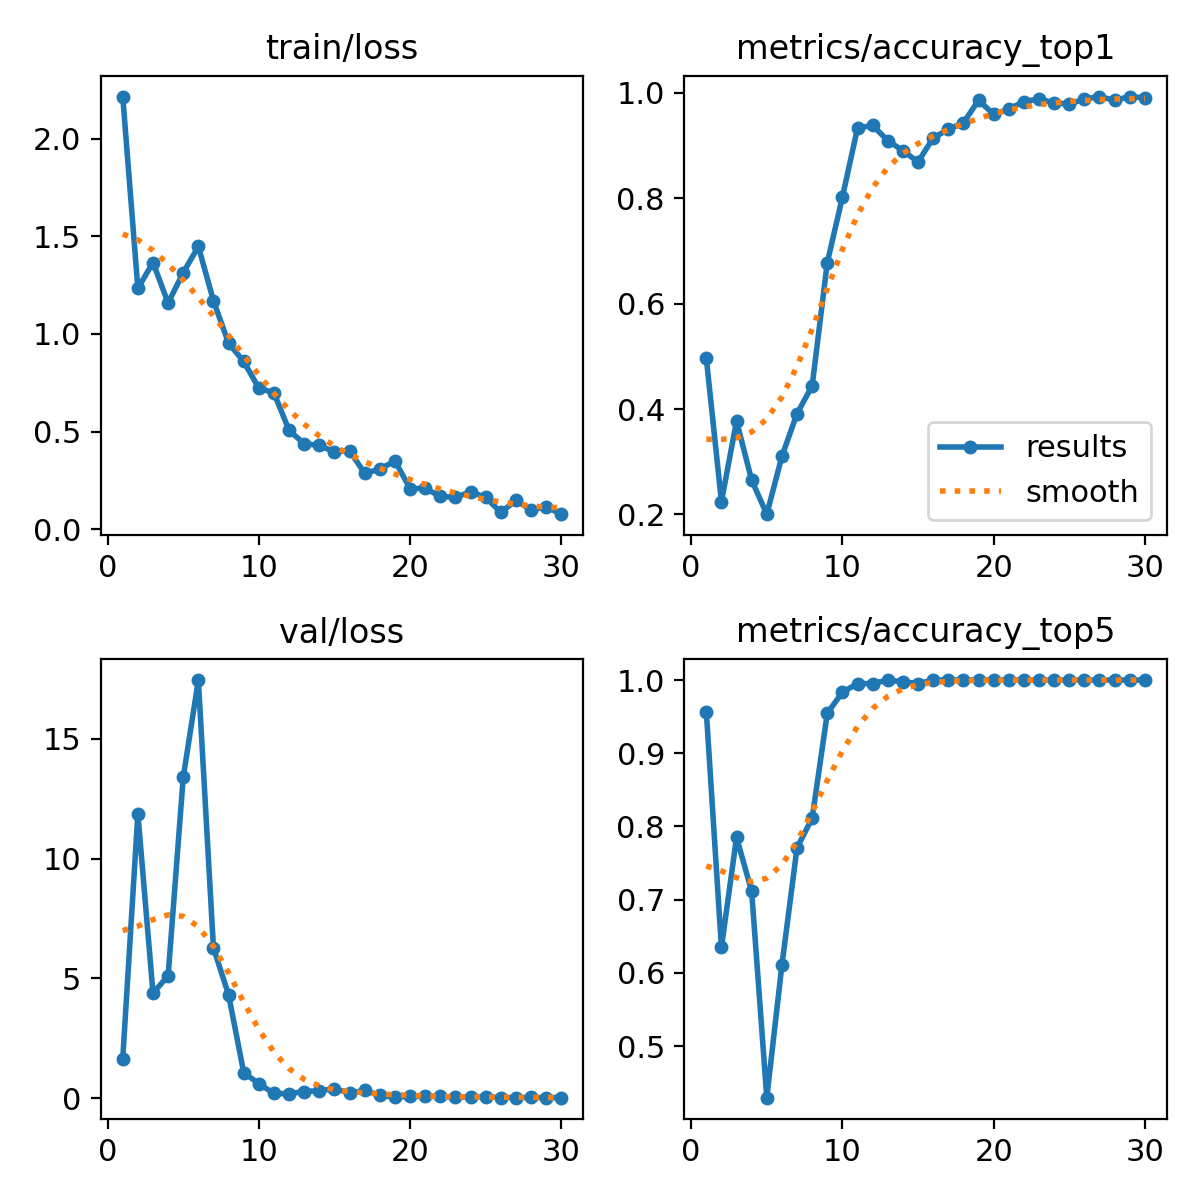

--------------------------------------------------
📈 confusion_matrix.png:


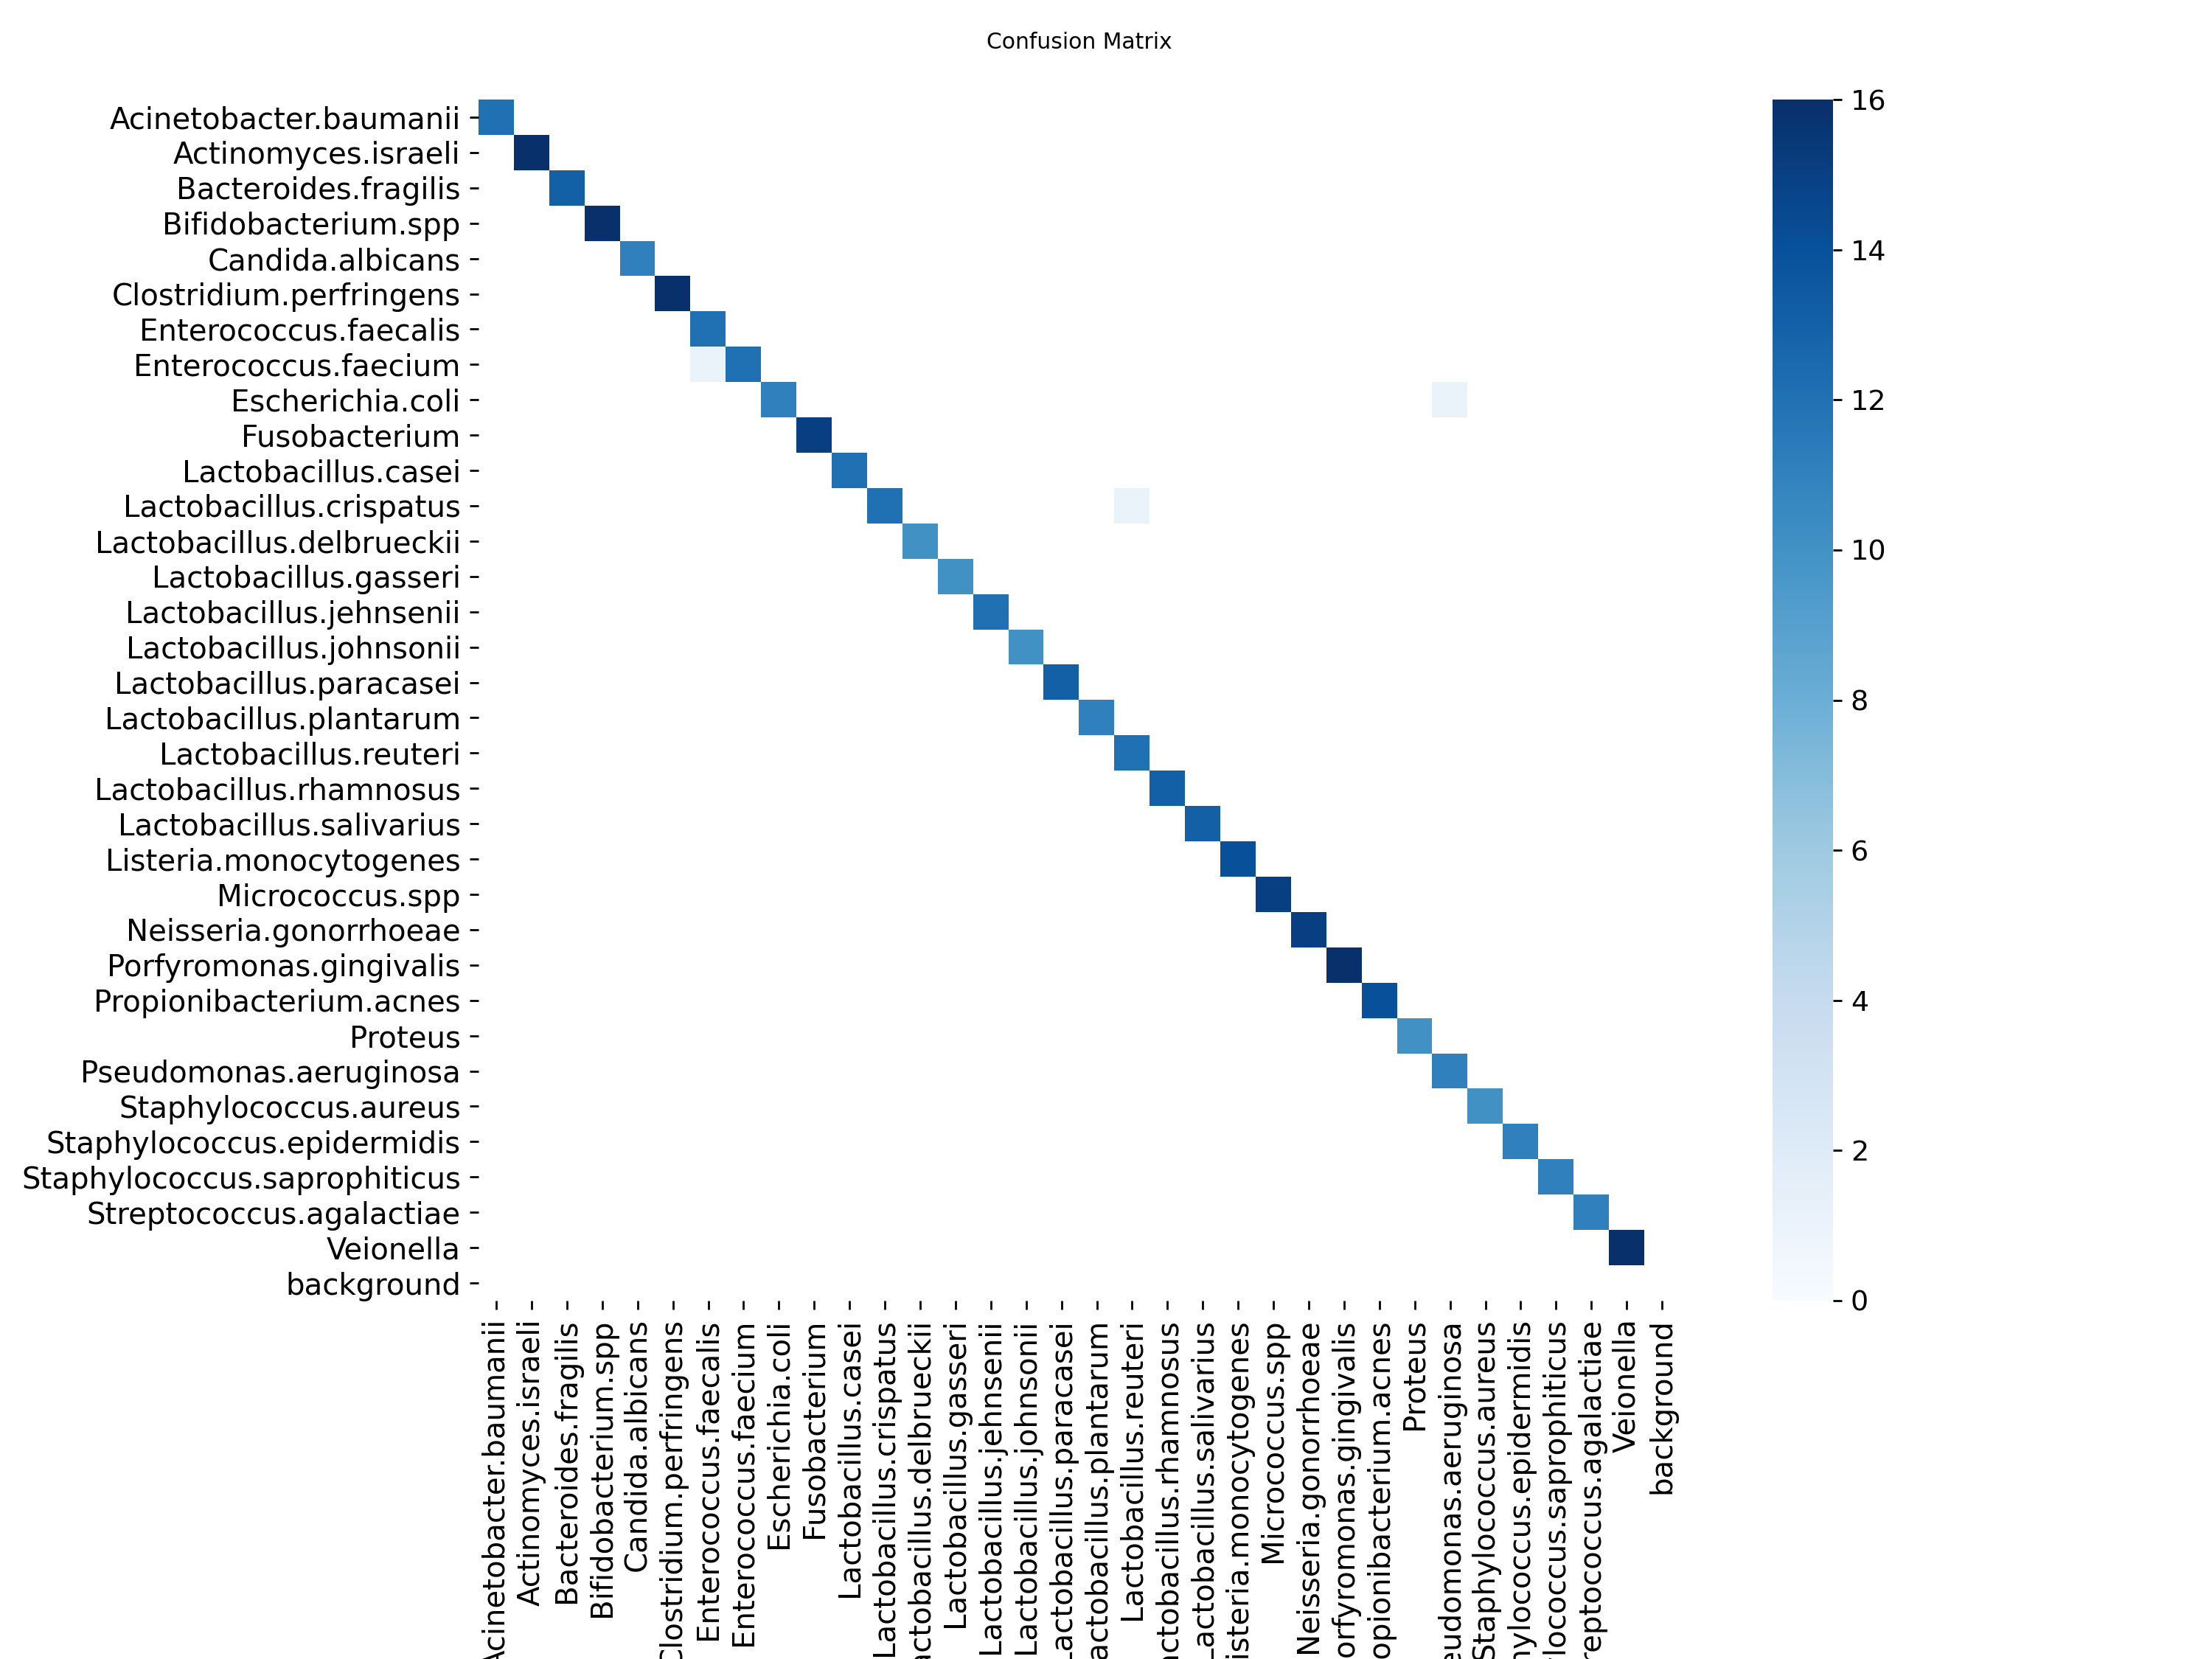

--------------------------------------------------
📈 confusion_matrix_normalized.png:


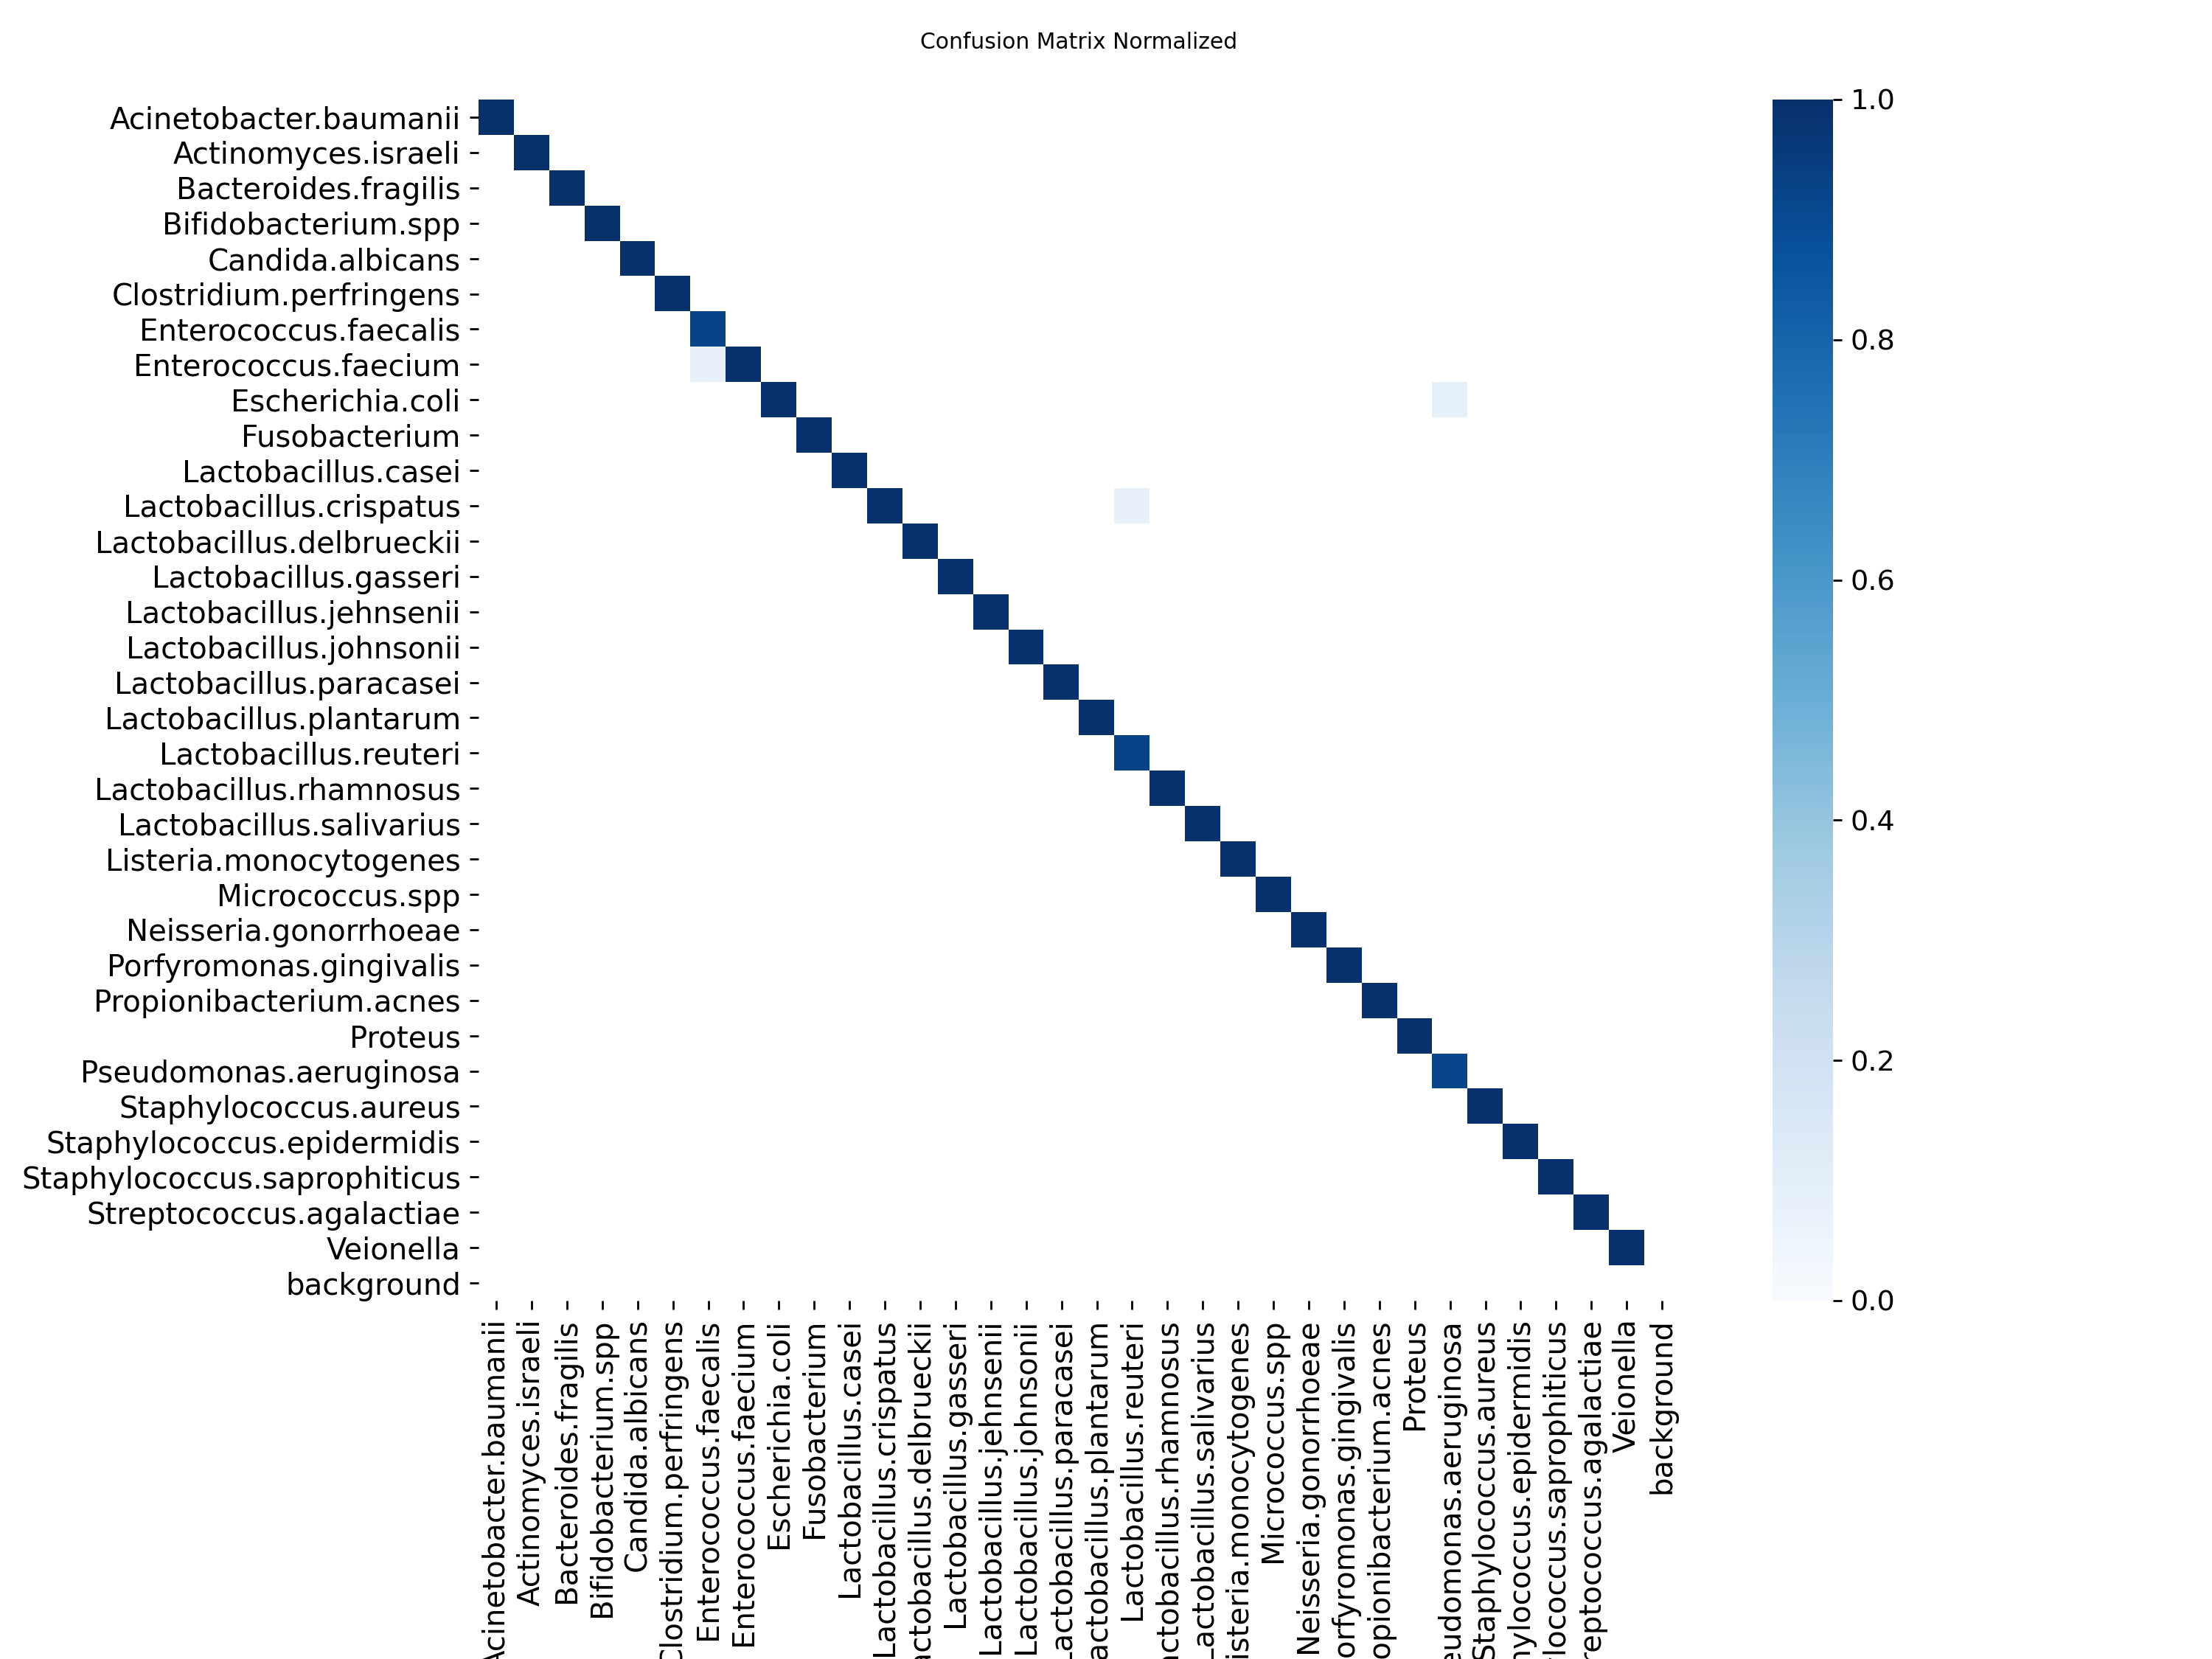

--------------------------------------------------
❌ labels.jpg не найден
❌ labels_correlogram.jpg не найден


In [9]:
from IPython.display import Image, display
import os

def show_interactive_plots():
    """Интерактивный просмотр графиков"""
    
    plots_dir = "runs/classify/train/"
    
    # Основные графики для показа
    important_plots = [
        'results.png',
        'confusion_matrix.png', 
        'confusion_matrix_normalized.png',
        'labels.jpg',
        'labels_correlogram.jpg'
    ]
    
    for plot_name in important_plots:
        plot_path = os.path.join(plots_dir, plot_name)
        if os.path.exists(plot_path):
            print(f"📈 {plot_name}:")
            display(Image(filename=plot_path, width=600))
            print("-" * 50)
        else:
            print(f"❌ {plot_name} не найден")

# Показываем интерактивно
show_interactive_plots()